# Лабораторная работа №3

**Тема:** Построение выпуклой оболочки бинарного объекта на основе преобразований утолщения

**Студент:** Косило Павел Андреевич

## 1. Теоретическая справка

Операция **утолщения** (thickening) $\odot$ множества $X$ составным структурирующим элементом $T = (A, B)$ определяется через объединение исходного множества и результата операции совпадения (Hit-or-Miss, $\otimes$):

$$
X \odot T = X \cup (X \otimes T)
$$

Для построения 45-выпуклой оболочки применяется итерационное утолщение с использованием двух базовых структурирующих элементов и их поворотов на $90^\circ$, что даёт 8 эффективных масок. Эти маски обнаруживают вогнутые участки границы и последовательно достраивают их пикселями переднего плана.

Итерационный процесс имеет вид:

$$
\psi(X) = (\dots((X \odot T_1) \odot T_2)\dots) \odot T_8
$$

Преобразования повторяются до сходимости, то есть до момента, когда очередной полный проход по всем маскам перестаёт изменять изображение. Результатом является 45-выпуклая оболочка бинарного объекта.

## 2. Исходные изображения

В работе используется программно сформированное бинарное изображение в форме буквы «С», содержащее выраженную вогнутость. Такой пример удобен для демонстрации алгоритма: в процессе утолщения вогнутая область постепенно заполняется, и объект переходит к своей 45-выпуклой оболочке.

Все вычисления выполняются для бинарного изображения со значениями пикселей `0` и `255`.

## 3. Код программы

Ниже приведён код, который:

1. Формирует исходное бинарное изображение.
2. Создаёт структурирующие элементы для утолщения и их повороты.
3. Выполняет построение выпуклой оболочки через итерационное утолщение до сходимости.
4. Выводит количественные характеристики результата и визуализирует полученную оболочку.

Количество полных циклов утолщения: 135
Количество пикселей исходного объекта: 11521
Количество пикселей выпуклой оболочки: 14641
Количество добавленных пикселей: 3120


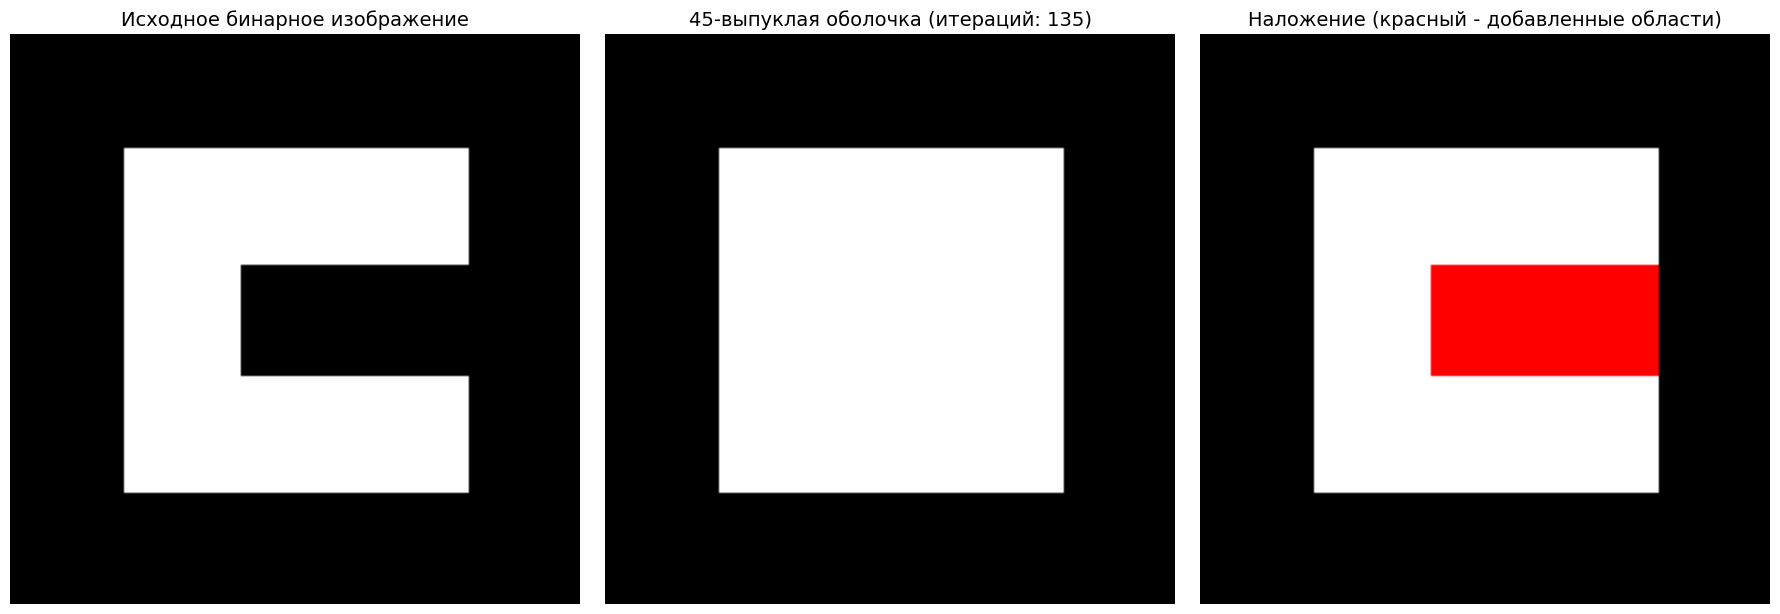

In [9]:
import importlib
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "cv2": "opencv-python",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
}

for module_name, package_name in REQUIRED_PACKAGES.items():
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])
        importlib.invalidate_caches()

cv2 = importlib.import_module("cv2")
np = importlib.import_module("numpy")
plt = importlib.import_module("matplotlib.pyplot")

def create_synthetic_image():
    """Создает тестовое бинарное изображение с выраженной вогнутостью."""
    image = np.zeros((200, 200), dtype=np.uint8)
    points = np.array(
        [[40, 40], [160, 40], [160, 80], [80, 80], [80, 120], [160, 120], [160, 160], [40, 160]],
        dtype=np.int32,
    )
    cv2.fillPoly(image, [points], 255)
    return image

def get_convex_hull_kernels():
    """Возвращает 8 структурирующих элементов для 45-выпуклой оболочки."""
    base_1 = np.array([
        [1, 1, 0],
        [1, -1, 0],
        [1, 0, -1],
    ], dtype=np.int8)
    base_2 = np.array([
        [0, 1, 1],
        [0, -1, 1],
        [-1, 0, 1],
    ], dtype=np.int8)

    kernels = []
    for rotation in range(4):
        kernels.append(np.rot90(base_1, rotation).astype(np.int8))
        kernels.append(np.rot90(base_2, rotation).astype(np.int8))

    return kernels

def hit_or_miss(binary_image, kernel):
    """Реализует операцию совпадения через эрозии объекта и фона."""
    foreground_mask = (kernel == 1).astype(np.uint8)
    background_mask = (kernel == -1).astype(np.uint8)

    if np.any(foreground_mask):
        foreground_match = cv2.erode(
            binary_image, foreground_mask, borderType=cv2.BORDER_CONSTANT, borderValue=0
        )
    else:
        foreground_match = np.ones_like(binary_image)

    if np.any(background_mask):
        background_match = cv2.erode(
            1 - binary_image, background_mask, borderType=cv2.BORDER_CONSTANT, borderValue=0
        )
    else:
        background_match = np.ones_like(binary_image)

    return cv2.bitwise_and(foreground_match, background_match)

def morphological_convex_hull(image):
    """Выполняет итерационное утолщение до получения 45-выпуклой оболочки."""
    hull = (image > 0).astype(np.uint8)
    kernels = get_convex_hull_kernels()
    iteration_count = 0

    while True:
        previous = hull.copy()
        for kernel in kernels:
            hit_miss = hit_or_miss(hull, kernel)
            hull = np.where(hit_miss > 0, 1, hull).astype(np.uint8)

        iteration_count += 1
        if np.array_equal(hull, previous):
            break

    return (hull * 255).astype(np.uint8), iteration_count

original_image = create_synthetic_image()
convex_hull_image, total_iterations = morphological_convex_hull(original_image)

added_region = ((convex_hull_image > 0) & (original_image == 0)).astype(np.uint8)
object_pixels = int(np.count_nonzero(original_image))
hull_pixels = int(np.count_nonzero(convex_hull_image))
added_pixels = int(np.count_nonzero(added_region))

print(f"Количество полных циклов утолщения: {total_iterations}")
print(f"Количество пикселей исходного объекта: {object_pixels}")
print(f"Количество пикселей выпуклой оболочки: {hull_pixels}")
print(f"Количество добавленных пикселей: {added_pixels}")

overlay = np.zeros((original_image.shape[0], original_image.shape[1], 3), dtype=np.uint8)
overlay[convex_hull_image > 0] = [255, 0, 0]
overlay[original_image > 0] = [255, 255, 255]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(original_image, cmap="gray")
axes[0].set_title("Исходное бинарное изображение", fontsize=14)
axes[0].axis("off")

axes[1].imshow(convex_hull_image, cmap="gray")
axes[1].set_title(f"45-выпуклая оболочка (итераций: {total_iterations})", fontsize=14)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title("Наложение (красный - добавленные области)", fontsize=14)
axes[2].axis("off")

plt.tight_layout()
plt.show()

## 4. Результат работы программы

После выполнения кода в ноутбуке формируются три изображения и текстовый вывод с количественными характеристиками результата:

1. **Исходное бинарное изображение** с выраженной вогнутостью.
2. **45-выпуклая оболочка**, полученная итерационным утолщением до сходимости.
3. **Наложение оболочки на исходный объект**, где добавленные области выделены красным цветом.

Дополнительно программа выводит количество полных циклов утолщения, число пикселей исходного объекта, число пикселей выпуклой оболочки и количество пикселей, добавленных при достраивании оболочки.

**Анализ результата:** вогнутая область исходной фигуры последовательно заполняется, а итоговая форма становится выпуклой в 45-градусной цифровой метрике. Это соответствует требованиям задания на построение выпуклой оболочки бинарного объекта на основе преобразований утолщения.